# Data Preprocessing Assignment
## Titanic Dataset – Machine Learning from Disaster
**Student Name:** ALJOWRY ALALI 
**Course / Section:** 6F03    

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv
/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/test.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/shuofxz/titanic-machine-learning-from-disaster/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 1: Dataset Overview
In this step, we load the Titanic dataset and inspect its structure, summary statistics, and initial data quality issues.

In [4]:
print("Shape:", df.shape)
df.info()


Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Task 1: Identify Data Quality Issues
We check:
- Missing values
- Duplicates
- Data types consistency
- Potential outliers

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

### Comment (Missing Values)
From the results:
- **Age** has missing values.
- **Cabin** has many missing values (high missing rate).
- **Embarked** has few missing values.
These issues must be handled before applying scaling and PCA.

In [7]:
df.duplicated().sum()

np.int64(0)

### Comment (Duplicates)
If duplicates exist, they may bias the analysis.  
In this dataset, the number of duplicated rows is shown above.

In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Comment (Data Types)
We confirm that numerical features are stored as numeric types and categorical features are stored correctly.  
This helps avoid errors during scaling and PCA.

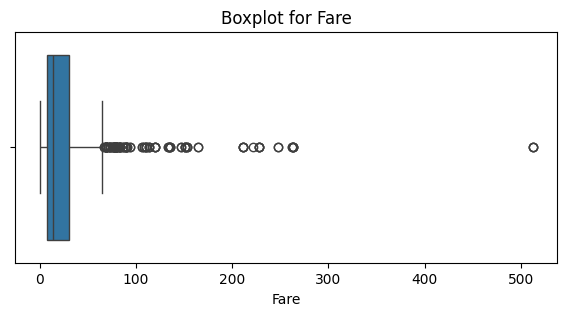

In [9]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot for Fare")
plt.show()

### Comment (Outliers)
The boxplot suggests that **Fare** contains extreme values (outliers).  
We will handle outliers using the **IQR method** in Task 3.

## Task 2: Handling Missing Values
We apply one strategy for missing values:
- **Age:** fill with Median (robust to outliers and skewness)
- **Embarked:** fill with Mode (categorical)
- **Cabin:** drop column (too many missing values)

In [10]:
df_clean = df.copy()

# Age -> Median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked -> Mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin -> Drop
df_clean.drop(columns=['Cabin'], inplace=True)

df_clean.isnull().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Comment (Missing Value Strategy)
- **Median** was used for Age because it is less sensitive to extreme values.
- **Mode** was used for Embarked because it is a categorical feature.
- **Cabin** was removed because the missing rate is too high, making it unreliable for analysis.

## Task 3: Detecting and Handling Outliers Using IQR
We detect outliers using:
- Q1 (25th percentile)
- Q3 (75th percentile)
- IQR = Q3 − Q1  
Outliers are values < lower bound or > upper bound.
We handle them using **capping (clipping)** to keep all observations.

In [11]:
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-26.724), np.float64(65.6344))

In [12]:
df_clean['Fare'] = df_clean['Fare'].clip(lower_bound, upper_bound)

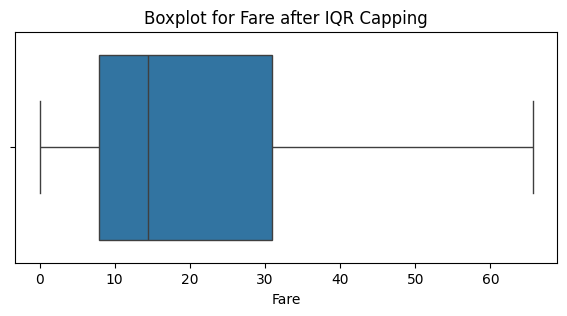

In [13]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df_clean['Fare'])
plt.title("Boxplot for Fare after IQR Capping")
plt.show()

### Comment (IQR Outlier Handling)
We capped Fare values to the IQR bounds to reduce the effect of extreme values while preserving the dataset size.

## Task 4: Data Normalization
We apply normalization to numerical features:
- **Min-Max Scaling** (range 0 to 1)
- **Z-score Standardization** (mean 0, std 1)

In [14]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df_clean[numerical_cols].head()

,Age,Fare,SibSp,Parch
0,22.0,7.2500,1,0
1,38.0,65.6344,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


### 4.1 Min-Max Scaling

In [15]:
df_minmax = df_clean.copy()
minmax_scaler = MinMaxScaler()

df_minmax[numerical_cols] = minmax_scaler.fit_transform(df_minmax[numerical_cols])
df_minmax[numerical_cols].head()

,Age,Fare,SibSp,Parch
0,0.271174,0.110460,0.125,0.0
1,0.472229,1.000000,0.125,0.0
2,0.321438,0.120745,0.000,0.0
3,0.434531,0.809027,0.125,0.0
4,0.434531,0.122649,0.000,0.0


### Comment (Min-Max Scaling)
Min-Max scaling converts features to the same scale between 0 and 1.  
This is useful when features have different units or ranges.

### 4.2 Z-score Standardization

In [16]:
df_standard = df_clean.copy()
standard_scaler = StandardScaler()

df_standard[numerical_cols] = standard_scaler.fit_transform(df_standard[numerical_cols])
df_standard[numerical_cols].head()

,Age,Fare,SibSp,Parch
0,-0.565736,-0.820552,0.432793,-0.473674
1,0.663861,2.031623,0.432793,-0.473674
2,-0.258337,-0.787578,-0.474545,-0.473674
3,0.433312,1.419297,0.432793,-0.473674
4,0.433312,-0.781471,-0.474545,-0.473674


### Comment (Z-score Standardization)
Standardization transforms features so they have mean = 0 and standard deviation = 1.  
This is often preferred before PCA.

## Task 5: Correlation Analysis and PCA
PCA should be applied only if numerical features show correlation.  
We first compute the correlation matrix. If correlation exists, PCA can reduce dimensionality while preserving variance.

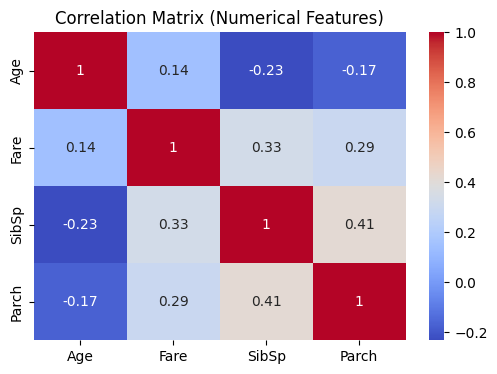

,Age,Fare,SibSp,Parch
Age,1.000000,0.144204,-0.233296,-0.172482
Fare,0.144204,1.000000,0.332021,0.292616
SibSp,-0.233296,0.332021,1.000000,0.414838
Parch,-0.172482,0.292616,0.414838,1.000000


In [17]:
corr = df_clean[numerical_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

corr

### Comment (PCA Decision)
If the correlation matrix shows relationships between numerical features (non-zero correlations), PCA is appropriate.  
Since the features show correlation, we apply PCA using the standardized dataset.

In [18]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_standard[numerical_cols])

pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,-0.255405,-0.953054
1,0.770287,1.695985
2,-0.874078,-0.608828
3,0.541991,1.154336
4,-1.038676,-0.045278


In [19]:
pca.explained_variance_ratio_

array([0.43423382, 0.28378057])

## Final Conclusion
- We identified missing values, duplicates, data types, and outliers.
- Missing values were handled using median/mode and dropping high-missing columns.
- Outliers were handled using IQR capping.
- Numerical features were normalized using Min-Max and Z-score.
- PCA was applied after confirming correlation among numerical features, and the explained variance was reported.